# BTC and Thesis Analysis

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
from pandas_datareader import data as pdr
from datetime import datetime
plt.rcParams["figure.figsize"] = (12,6)

In [2]:
start_date = "2015-01-01"
end_date = datetime.today().strftime("%Y-%m-%d")
tickers = {
    "BTC": "BTC-USD",
    "Gold": "GLD",
    "SPY": "SPY",
    "QQQ": "QQQ",
    "TLT": "TLT",
    "VIX": "^VIX"
}
prices = pd.DataFrame()
for name, ticker in tickers.items():
    data = yf.download(ticker, start=start_date, end=end_date, auto_adjust=True)
    prices[name] = data["Close"]
prices = prices.dropna()
prices.head()

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


,BTC,Gold,SPY,QQQ,TLT,VIX
2015-01-02,315.032013,114.080002,169.687866,94.561134,92.659317,17.790001
2015-01-05,274.473999,115.800003,166.623352,93.174034,94.114815,19.920000
2015-01-06,286.188995,117.120003,165.053925,91.924751,95.810524,21.120001
2015-01-07,294.337006,116.430000,167.110718,93.109764,95.621330,19.309999
2015-01-08,283.348999,115.940002,170.076065,94.891869,94.354958,17.010000


In [3]:
prices.to_csv("../data/asset_prices.csv")

In [4]:
returns = prices.pct_change().dropna()
returns.head()

,BTC,Gold,SPY,QQQ,TLT,VIX
2015-01-05,-0.128743,0.015077,-0.018060,-0.014669,0.015708,0.119730
2015-01-06,0.042682,0.011399,-0.009419,-0.013408,0.018017,0.060241
2015-01-07,0.028471,-0.005891,0.012461,0.012891,-0.001975,-0.085701
2015-01-08,-0.037331,-0.004209,0.017745,0.019140,-0.013244,-0.119109
2015-01-09,0.024913,0.011385,-0.008013,-0.006583,0.010953,0.031746


## Formulas that I'll be using

### Notation Guide

The formulas below use several mathematical symbols and variables:

- **t** — A specific day in the dataset.
- **N** — Total number of trading days in the dataset.
- **r_t** — Return (gain or loss) on day t, expressed as a decimal.
- **∏ (product operator)** — Multiplies a sequence of values together.
- **P_t** — Portfolio value (or asset price) on day t.
- **M_t** — Highest portfolio value observed up to day t.
- **σ (sigma)** — Standard deviation, a measure of variability or risk.
- **σ_daily** — Standard deviation of daily returns.
- **R_ann** — Annualized return.
- **σ_ann** — Annualized volatility.
- **R_f** — Risk-free rate.
- **√252** — Square root of 252, used to annualize volatility.
- **min** — Selects the smallest value from a set of values.

### Annualized Return

Annualized return estimates the average yearly growth rate of an investment while accounting for compounding.

First, calculate the cumulative growth of the investment:

$$
\text{Cumulative Return}
=
\prod_{t=1}^{N}(1+r_t)
$$

Next, convert the number of trading days into years:

$$
\text{Years}
=
\frac{N}{252}
$$

Finally, annualize the cumulative return:

$$
R_{ann}
=
\left(
\prod_{t=1}^{N}(1+r_t)
\right)^{\frac{252}{N}}
-1
$$

This represents the average yearly return that would produce the same overall growth.

### Annualized Volatility

Volatility measures how much returns fluctuate over time. Higher volatility generally indicates greater risk.

$$
\sigma_{ann}
=
\sigma_{daily}\sqrt{252}
$$

### Sharpe Ratio

The Sharpe Ratio measures how much return an investment generates relative to the amount of risk taken.

$$
\text{Sharpe Ratio}
=
\frac{R_{ann}-R_f}{\sigma_{ann}}
$$

A higher Sharpe Ratio generally indicates better risk-adjusted performance.

### Maximum Drawdown

Drawdown measures how far a portfolio has fallen from its previous peak value.

$$
\text{Drawdown}_t
=
\frac{P_t}{M_t}-1
$$

Maximum Drawdown is the largest loss from a peak to a subsequent trough during the observation period:

$$
\text{Maximum Drawdown}
=
\min_t
\left(
\frac{P_t}{M_t}-1
\right)
$$

A more negative maximum drawdown indicates a larger historical loss from a previous high.

In [5]:
def annualized_return(daily_returns):
    cumulative_return = (1 + daily_returns).prod()
    years = len(daily_returns) / 252
    return cumulative_return ** (1 / years) - 1

def annualized_volatility(daily_returns):
    return daily_returns.std() * np.sqrt(252)

def sharpe_ratio(daily_returns, risk_free_rate=0.0):
    ann_return = annualized_return(daily_returns)
    ann_vol = annualized_volatility(daily_returns)
    return (ann_return - risk_free_rate) / ann_vol

def max_drawdown(price_series):
    cumulative_max = price_series.cummax()
    drawdown = price_series / cumulative_max - 1
    return drawdown.min()

def drawdown_series(price_series):
    cumulative_max = price_series.cummax()
    return price_series / cumulative_max - 1

## Thesis Test 1: Gold-Like Behavior

In [6]:
metrics = pd.DataFrame(index=prices.columns)
metrics["Annualized Return"] = returns.apply(annualized_return)
metrics["Annualized Volatility"] = returns.apply(annualized_volatility)
metrics["Sharpe Ratio"] = returns.apply(sharpe_ratio)
metrics["Max Drawdown"] = prices.apply(max_drawdown)
metrics = metrics.sort_values("Sharpe Ratio", ascending=False)
metrics

,Annualized Return,Annualized Volatility,Sharpe Ratio,Max Drawdown
QQQ,0.194462,0.219495,0.885954,-0.351187
BTC,0.580750,0.661512,0.877913,-0.830363
SPY,0.137844,0.176499,0.780989,-0.337173
Gold,0.108240,0.160423,0.674716,-0.262109
VIX,-0.006073,1.370342,-0.004432,-0.856573
TLT,-0.006969,0.148479,-0.046939,-0.483512


## Correlation Matrix

In [7]:
core_returns = returns[["BTC", "Gold", "SPY"]]
correlation_matrix = core_returns.corr()
correlation_matrix

,BTC,Gold,SPY
BTC,1.000000,0.094178,0.231396
Gold,0.094178,1.000000,0.066590
SPY,0.231396,0.066590,1.000000


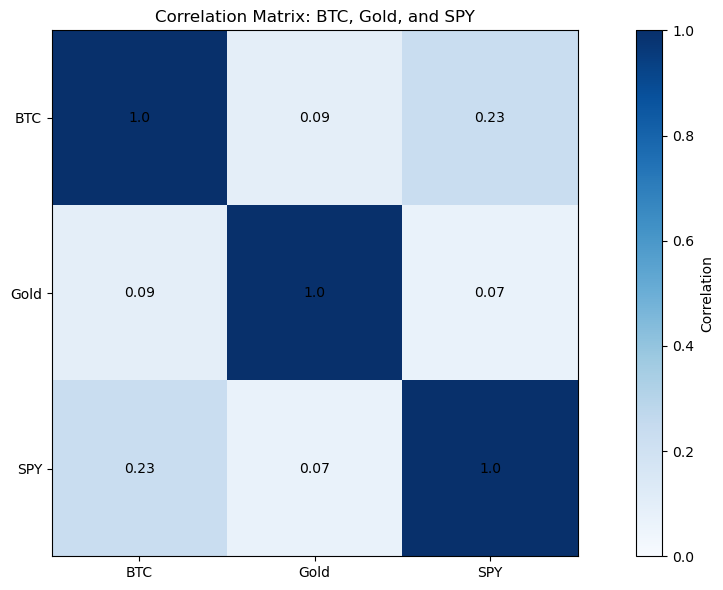

In [8]:
plt.figure()
plt.imshow(correlation_matrix, cmap="Blues", interpolation="nearest", vmin=0, vmax=1)
plt.colorbar(label="Correlation")
plt.xticks(range(len(correlation_matrix.columns)), correlation_matrix.columns)
plt.yticks(range(len(correlation_matrix.index)), correlation_matrix.index)
for i in range(len(correlation_matrix.index)):
    for j in range(len(correlation_matrix.columns)):
        plt.text(j, i, round(correlation_matrix.iloc[i, j], 2), ha="center", va="center", color="black")
plt.title("Correlation Matrix: BTC, Gold, and SPY")
plt.tight_layout()
plt.savefig("../charts/correlation_matrix.png")
plt.show()

## Rolling correlation chart

In [9]:
rolling_window = 270
rolling_corr_btc_spy = returns["BTC"].rolling(rolling_window).corr(returns["SPY"])
rolling_corr_btc_gold = returns["BTC"].rolling(rolling_window).corr(returns["Gold"])

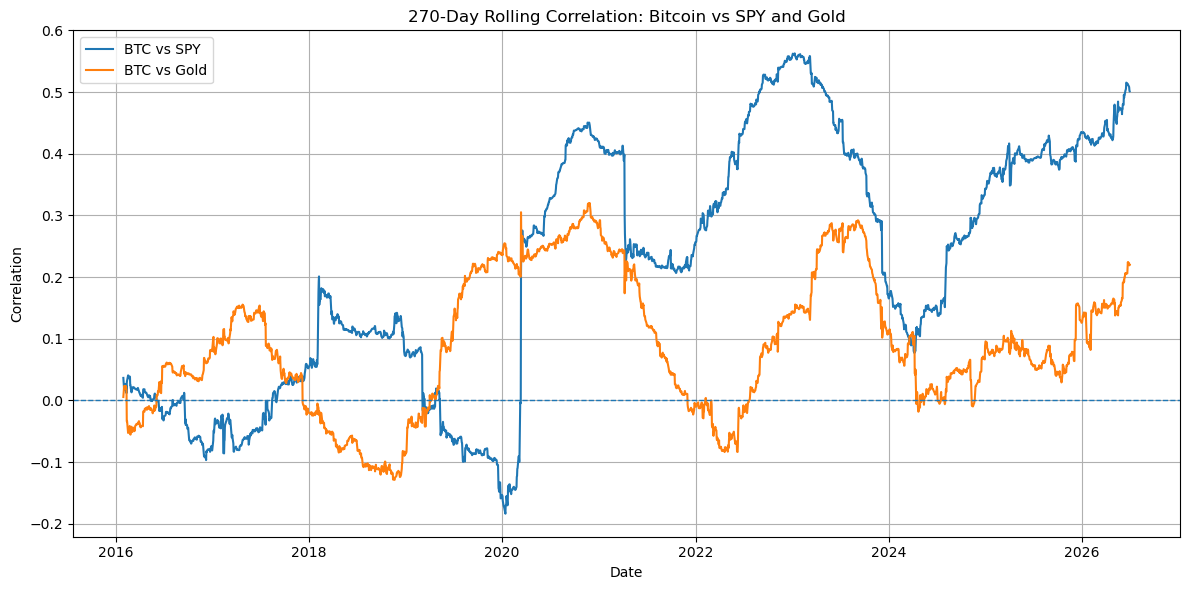

In [10]:
plt.figure()
plt.plot(rolling_corr_btc_spy.index, rolling_corr_btc_spy, label="BTC vs SPY")
plt.plot(rolling_corr_btc_gold.index, rolling_corr_btc_gold, label="BTC vs Gold")
plt.axhline(0, linestyle="--", linewidth=1)
plt.title("270-Day Rolling Correlation: Bitcoin vs SPY and Gold")
plt.xlabel("Date")
plt.ylabel("Correlation")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("../charts/rolling_correlation.png")
plt.show()

## Drawdowns

In [11]:
core_prices = prices[["BTC", "Gold", "SPY"]]
drawdowns = core_prices.apply(drawdown_series)
drawdowns.tail()

,BTC,Gold,SPY
2026-06-25,-0.521279,-0.254971,-0.030778
2026-06-26,-0.518916,-0.246562,-0.037787
2026-06-29,-0.517939,-0.256745,-0.021935
2026-06-30,-0.530600,-0.257149,-0.014319
2026-07-01,-0.519018,-0.252672,-0.015652


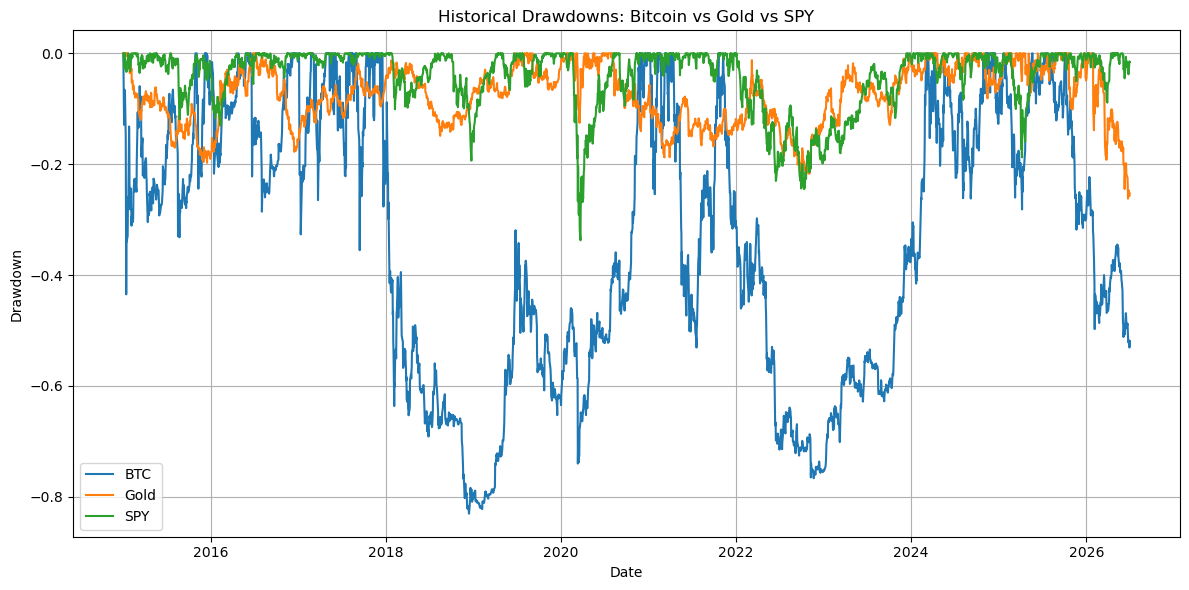

In [12]:
plt.figure()
for asset in drawdowns.columns:
    plt.plot(drawdowns.index, drawdowns[asset], label=asset)
plt.title("Historical Drawdowns: Bitcoin vs Gold vs SPY")
plt.xlabel("Date")
plt.ylabel("Drawdown")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("../charts/drawdowns.png")
plt.show()

## Thesis Test 2: Inflation Hedge Behavior

In [13]:
cpi = pdr.DataReader("CPIAUCSL", "fred", start_date, end_date)
cpi = cpi.rename(columns={"CPIAUCSL": "CPI"})
cpi["Inflation YoY"] = cpi["CPI"].pct_change(12, fill_method=None)
cpi.tail()

,CPI,Inflation YoY
DATE,,
2026-01-01,326.588,0.023912
2026-02-01,327.460,0.024340
2026-03-01,330.293,0.032860
2026-04-01,332.407,0.037792
2026-05-01,333.979,0.041666


## Monthly BTC returns vs inflation

In [14]:
monthly_prices = prices.resample("ME").last()
monthly_returns = monthly_prices.pct_change().dropna()
inflation_data = cpi.resample("ME").last()
btc_inflation = pd.concat(
    [monthly_returns["BTC"], inflation_data["Inflation YoY"]], axis=1
).dropna()
btc_inflation.columns = ["BTC Monthly Return", "Inflation YoY"]
btc_inflation.head()

,BTC Monthly Return,Inflation YoY
2016-01-31,-0.118664,0.012375
2016-02-29,0.153431,0.008473
2016-03-31,-0.047905,0.008916
2016-04-30,0.092069,0.011726
2016-05-31,0.167632,0.010785


In [15]:
btc_inflation_corr = btc_inflation.corr()
btc_inflation_corr

,BTC Monthly Return,Inflation YoY
BTC Monthly Return,1.000000,-0.231488
Inflation YoY,-0.231488,1.000000


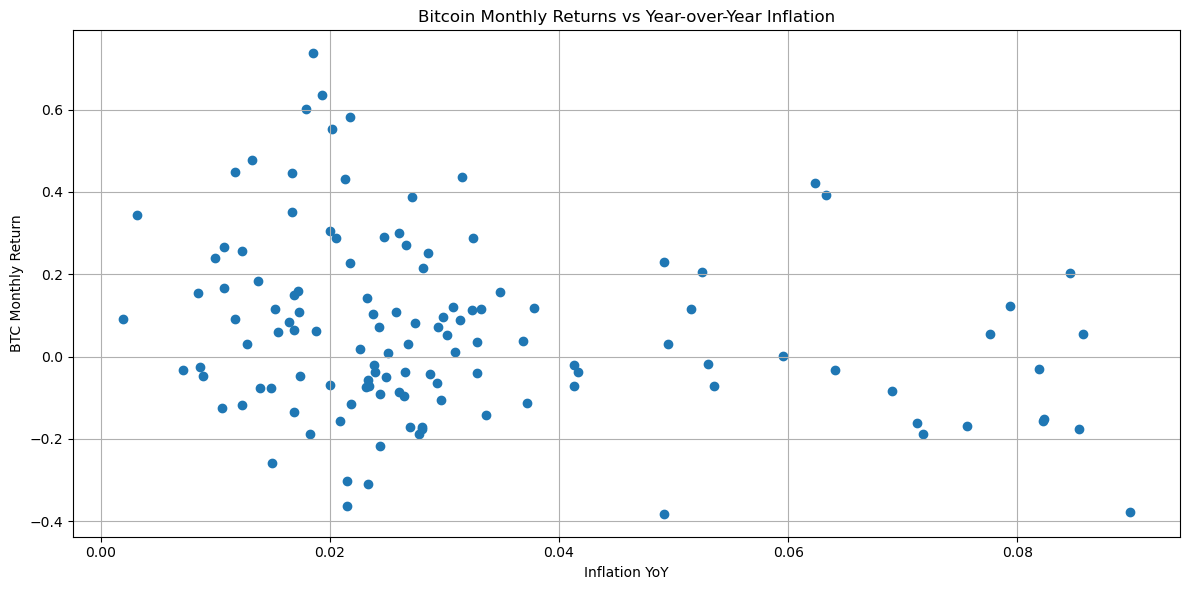

In [16]:
plt.figure()
plt.scatter(
    btc_inflation["Inflation YoY"],
    btc_inflation["BTC Monthly Return"]
)
plt.title("Bitcoin Monthly Returns vs Year-over-Year Inflation")
plt.xlabel("Inflation YoY")
plt.ylabel("BTC Monthly Return")
plt.grid(True)
plt.tight_layout()
plt.savefig("../charts/btc_vs_inflation.png")
plt.show()

## Initial Findings

In [17]:
print("INITIAL FINDINGS")
print("----------------")
print("1. Performance Metrics:")
print(metrics)
print("\n2. Correlation Matrix:")
print(correlation_matrix)
print("\n3. BTC vs Inflation Correlation:")
print(btc_inflation_corr)

INITIAL FINDINGS
----------------
1. Performance Metrics:
      Annualized Return  Annualized Volatility  Sharpe Ratio  Max Drawdown
QQQ            0.194462               0.219495      0.885954     -0.351187
BTC            0.580750               0.661512      0.877913     -0.830363
SPY            0.137844               0.176499      0.780989     -0.337173
Gold           0.108240               0.160423      0.674716     -0.262109
VIX           -0.006073               1.370342     -0.004432     -0.856573
TLT           -0.006969               0.148479     -0.046939     -0.483512

2. Correlation Matrix:
           BTC      Gold       SPY
BTC   1.000000  0.094178  0.231396
Gold  0.094178  1.000000  0.066590
SPY   0.231396  0.066590  1.000000

3. BTC vs Inflation Correlation:
                    BTC Monthly Return  Inflation YoY
BTC Monthly Return            1.000000      -0.231488
Inflation YoY                -0.231488       1.000000


## Inflation Regime Analysis

In [18]:
monthly_prices = prices.resample("ME").last()
monthly_returns = monthly_prices.pct_change().dropna()

monthly_returns_regime = monthly_returns.copy()
cpi_regime = cpi.copy()

monthly_returns_regime.index = monthly_returns_regime.index.to_period("M")

if not isinstance(cpi_regime.index, pd.PeriodIndex):
    cpi_regime.index = cpi_regime.index.to_period("M")

regime_data = monthly_returns_regime.merge(
    cpi_regime[["Inflation YoY"]],
    left_index=True,
    right_index=True,
    how="inner"
)

regime_data = regime_data.dropna(subset=["Inflation YoY"])

regime_data.head()

,BTC,Gold,SPY,QQQ,TLT,VIX,Inflation YoY
2016-01,-0.118664,0.054110,-0.049786,-0.069104,0.055731,0.109281,0.012375
2016-02,0.153431,0.109303,-0.000826,-0.015653,0.030860,0.017327,0.008473
2016-03,-0.047905,-0.008429,0.067266,0.068526,-0.000933,-0.321168,0.008916
2016-04,0.092069,0.051088,0.003941,-0.031868,-0.007365,0.125448,0.011726
2016-05,0.167632,-0.061383,0.017011,0.043700,0.008054,-0.096178,0.010785


In [19]:
def classify_inflation(inflation):
    if inflation < 0.02:
        return "Low Inflation"
    elif inflation < 0.04:
        return "Moderate Inflation"
    else:
        return "High Inflation"
regime_data["Inflation Regime"] = regime_data["Inflation YoY"].apply(classify_inflation)
regime_data[["Inflation YoY", "Inflation Regime"]].head()

,Inflation YoY,Inflation Regime
2016-01,0.012375,Low Inflation
2016-02,0.008473,Low Inflation
2016-03,0.008916,Low Inflation
2016-04,0.011726,Low Inflation
2016-05,0.010785,Low Inflation


In [20]:
regime_returns = (
    regime_data.groupby("Inflation Regime")[["BTC", "Gold", "SPY"]].mean()
)
order = [
    "Low Inflation",
    "Moderate Inflation",
    "High Inflation"
]
regime_returns = regime_returns.reindex(order)
regime_returns

,BTC,Gold,SPY
Inflation Regime,,,
Low Inflation,0.144439,0.012106,0.017107
Moderate Inflation,0.049878,0.015218,0.013072
High Inflation,-0.011142,0.005086,0.006345


In [21]:
annualized_regime_returns = (
    (1 + regime_returns) ** 12 - 1
)
order = [
    "Low Inflation",
    "Moderate Inflation",
    "High Inflation"
]
annualized_regime_returns = annualized_regime_returns.reindex(order)
annualized_regime_returns

,BTC,Gold,SPY
Inflation Regime,,,
Low Inflation,4.047910,0.155345,0.225743
Moderate Inflation,0.793346,0.198700,0.168653
High Inflation,-0.125804,0.062773,0.078859


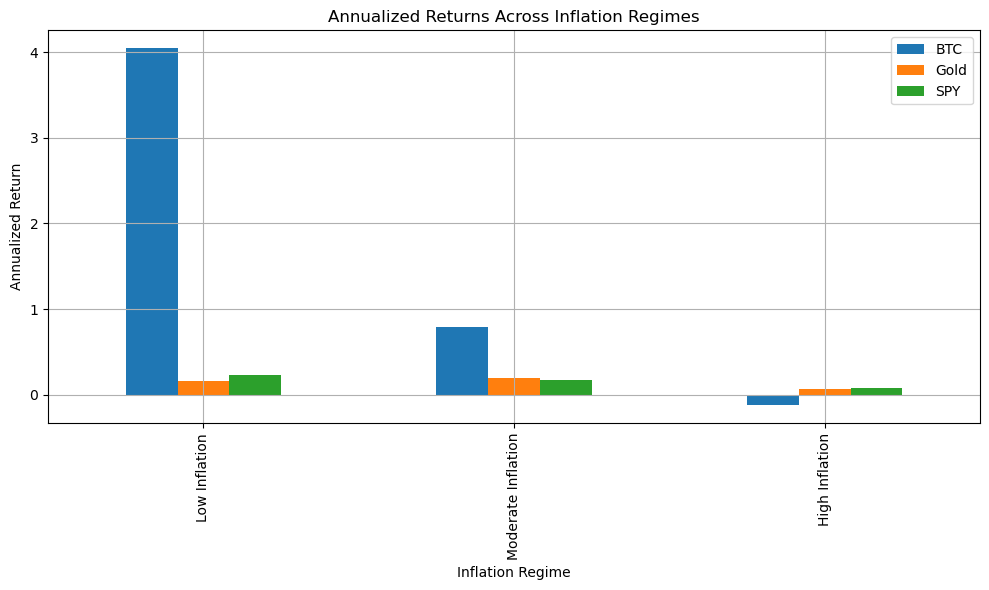

In [22]:
annualized_regime_returns.plot(
    kind="bar",
    figsize=(10,6)
)
plt.title("Annualized Returns Across Inflation Regimes")
plt.ylabel("Annualized Return")
plt.grid(True)
plt.tight_layout()
plt.savefig("../charts/regime_comparison.png")
plt.show()

In [23]:
regime_data["Inflation Regime"].value_counts()

Inflation Regime
Moderate Inflation    61
Low Inflation         36
High Inflation        27
Name: count, dtype: int64

In [24]:
regime_volatility = (
    regime_data
    .groupby("Inflation Regime")[["BTC", "Gold", "SPY"]]
    .std()
)

annualized_regime_volatility = (regime_volatility * np.sqrt(12))
annualized_regime_volatility

,BTC,Gold,SPY
Inflation Regime,,,
High Inflation,0.672646,0.142918,0.183967
Low Inflation,0.825145,0.170748,0.162763
Moderate Inflation,0.704888,0.143444,0.132284


In [25]:
print("\n4. Inflation Regime Analysis")
print("----------------------------")

print("\nObservation Count:")
print(regime_data["Inflation Regime"].value_counts())

print("\nAverage Monthly Returns:")
print((regime_returns * 100).round(2).astype(str) + "%")

print("\nAnnualized Returns:")
print((annualized_regime_returns * 100).round(2).astype(str) + "%")

print("\nInterpretation:")
print("- Bitcoin performed worst during high inflation periods.")
print("- Gold remained positive during high inflation periods.")
print("- Bitcoin generated its strongest returns during low inflation periods.")
print("- Initial evidence suggests Bitcoin behaves more like a risk asset than a traditional inflation hedge.")


4. Inflation Regime Analysis
----------------------------

Observation Count:
Inflation Regime
Moderate Inflation    61
Low Inflation         36
High Inflation        27
Name: count, dtype: int64

Average Monthly Returns:
                       BTC   Gold    SPY
Inflation Regime                        
Low Inflation       14.44%  1.21%  1.71%
Moderate Inflation   4.99%  1.52%  1.31%
High Inflation      -1.11%  0.51%  0.63%

Annualized Returns:
                        BTC    Gold     SPY
Inflation Regime                           
Low Inflation       404.79%  15.53%  22.57%
Moderate Inflation   79.33%  19.87%  16.87%
High Inflation      -12.58%   6.28%   7.89%

Interpretation:
- Bitcoin performed worst during high inflation periods.
- Gold remained positive during high inflation periods.
- Bitcoin generated its strongest returns during low inflation periods.
- Initial evidence suggests Bitcoin behaves more like a risk asset than a traditional inflation hedge.


## Thesis Test 3: Does Bitcoin Behave Like a Risk Asset

In [26]:
vix_data = returns.copy()
vix_data["VIX"] = prices["VIX"]
def classify_vix(vix):
    if vix < 20:
        return "Risk on"
    elif vix < 30:
        return "Netural"
    else:
        return "Risk off"
vix_data["Market Regime"] = vix_data["VIX"].apply(classify_vix)
vix_data[["BTC", "Gold", "SPY", "VIX", "Market Regime"]].head() 

,BTC,Gold,SPY,VIX,Market Regime
2015-01-05,-0.128743,0.015077,-0.018060,19.920000,Risk on
2015-01-06,0.042682,0.011399,-0.009419,21.120001,Netural
2015-01-07,0.028471,-0.005891,0.012461,19.309999,Risk on
2015-01-08,-0.037331,-0.004209,0.017745,17.010000,Risk on
2015-01-09,0.024913,0.011385,-0.008013,17.549999,Risk on


In [27]:
vix_counts = vix_data["Market Regime"].value_counts()
vix_counts

Market Regime
Risk on     2026
Netural      705
Risk off     158
Name: count, dtype: int64

In [28]:
vix_regime_returns = (
    vix_data.groupby("Market Regime")[["BTC", "Gold", "SPY"]].mean()
)
vix_regime_annual_returns = (1 + vix_regime_returns) ** 252 - 1
vix_regime_volatility = (
    vix_data.groupby("Market Regime")[["BTC", "Gold", "SPY"]].std() * np.sqrt(252)
)
vix_order = [
    "Risk on",
    "Netural",
    "Risk off"
]
vix_regime_annual_returns = vix_regime_annual_returns.reindex(vix_order)
vix_regime_volatility = vix_regime_volatility.reindex(vix_order)
print("Annualized Returns by VIX Regime")
display(vix_regime_annual_returns)
print("Annualized Volatility by VIX Regime")
display(vix_regime_volatility)

Annualized Returns by VIX Regime


,BTC,Gold,SPY
Market Regime,,,
Risk on,1.371447,0.078889,0.450152
Netural,0.741653,0.241005,-0.175662
Risk off,-0.689725,0.194626,-0.717359


Annualized Volatility by VIX Regime


,BTC,Gold,SPY
Market Regime,,,
Risk on,0.606345,0.145088,0.104928
Netural,0.729342,0.181740,0.204372
Risk off,0.952166,0.231325,0.480810


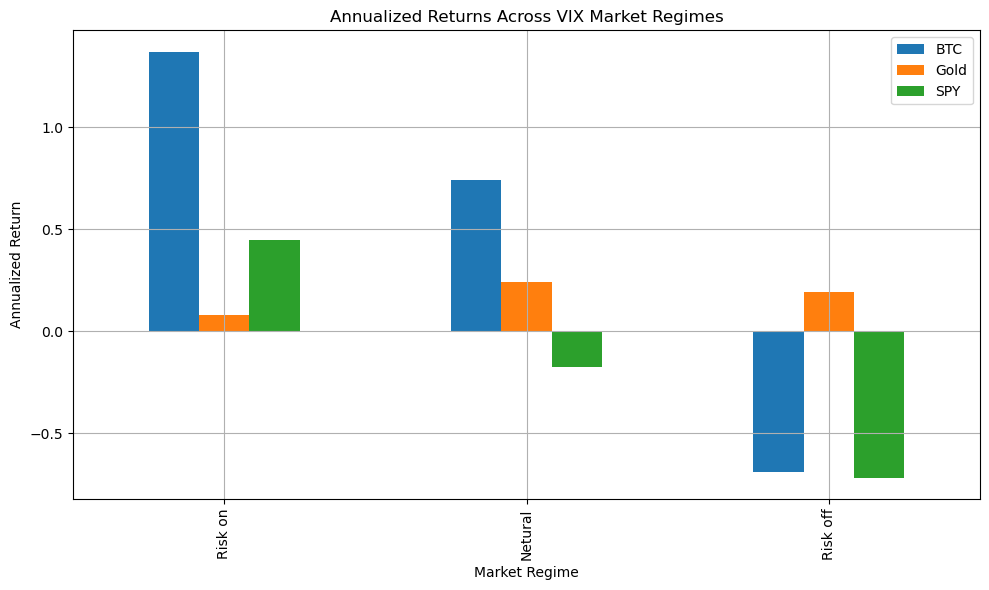

In [29]:
vix_regime_annual_returns.plot(kind="bar", figsize=(10, 6))

plt.title("Annualized Returns Across VIX Market Regimes")
plt.xlabel("Market Regime")
plt.ylabel("Annualized Return")
plt.grid(True)
plt.tight_layout()
plt.savefig("../charts/vix_regime_returns.png")
plt.show()

### RISK-ON / RISK-OFF ANALYSIS

- During risk-on environments, Bitcoin generated the strongest returns among all assets.
- During risk-off environments, Bitcoin experienced losses similar to equities.
- Gold remained positive during risk-off periods, while Bitcoin and equities declined.
- These results suggest Bitcoin currently behaves more like a risk asset than a traditional safe-haven asset.
- The evidence does not support Bitcoin functioning as digital gold during periods of market stress.

## Thesis Test 4: Stress-Period Behavior

In [30]:
stress_periods = {
    "COVID Crash": ("2020-02-19", "2020-03-23"),
    "COVID Recovery Window": ("2020-02-19", "2020-08-31"),
    "2022 Inflation/Tightening Cycle": ("2022-01-01", "2022-12-31")
}
core_assets = ["BTC", "Gold", "SPY"]

In [31]:
def cumulative_return(return_series):
    return (1 + return_series).prod() - 1

def max_drawdown_from_prices(price_series):
    running_max = price_series.cummax()
    drawdown = price_series / running_max - 1
    return drawdown.min()

def recovery_days_from_trough(price_series):
    starting_value = price_series.iloc[0]
    
    running_max = price_series.cummax()
    drawdown = price_series / running_max - 1
    trough_date = drawdown.idxmin()
    
    after_trough = price_series.loc[trough_date:]
    recovered = after_trough[after_trough >= starting_value]
    
    if len(recovered) == 0:
        return np.nan
    
    return (recovered.index[0] - trough_date).days

In [32]:
stress_results = []
for period_name, (start, end) in stress_periods.items():
    period_prices = prices.loc[start:end, core_assets]
    period_returns = returns.loc[start:end, core_assets]
    for asset in core_assets:
        stress_results.append({
            "Period": period_name,
            "Asset": asset,
            "Cumulative Return": cumulative_return(period_returns[asset]),
            "Max Drawdown": max_drawdown_from_prices(period_prices[asset]),
            "Recovery Days": recovery_days_from_trough(period_prices[asset])
        })

stress_results_df = pd.DataFrame(stress_results)
stress_results_df["Recovery Days"] = stress_results_df["Recovery Days"].fillna("Not Recovered")
stress_results_df

,Period,Asset,Cumulative Return,Max Drawdown,Recovery Days
0,COVID Crash,BTC,-0.367352,-0.486830,Not Recovered
1,COVID Crash,Gold,-0.030548,-0.125277,Not Recovered
2,COVID Crash,SPY,-0.334003,-0.337173,Not Recovered
3,COVID Recovery Window,BTC,0.151728,-0.486830,56.0
4,COVID Recovery Window,Gold,0.224770,-0.125277,5.0
5,COVID Recovery Window,SPY,0.048051,-0.337173,140.0
6,2022 Inflation/Tightening Cycle,BTC,-0.641463,-0.667396,Not Recovered
7,2022 Inflation/Tightening Cycle,Gold,-0.007721,-0.210328,78.0
8,2022 Inflation/Tightening Cycle,SPY,-0.181754,-0.244964,Not Recovered


In [33]:
stress_return_table = stress_results_df.pivot(
    index="Period",
    columns="Asset",
    values="Cumulative Return"
)

stress_drawdown_table = stress_results_df.pivot(
    index="Period",
    columns="Asset",
    values="Max Drawdown"
)

stress_recovery_table = stress_results_df.pivot(
    index="Period",
    columns="Asset",
    values="Recovery Days"
)
stress_order = [
    "COVID Crash",
    "COVID Recovery Window",
    "2022 Inflation/Tightening Cycle"
]
stress_return_table = stress_return_table.reindex(stress_order)
stress_drawdown_table = stress_drawdown_table.reindex(stress_order)
stress_recovery_table = stress_recovery_table.reindex(stress_order)

print("Cumulative Returns During Stress Periods")
display(stress_return_table)

print("Maximum Drawdowns During Stress Periods")
display(stress_drawdown_table)

print("Recovery Days After Trough")
display(stress_recovery_table)

Cumulative Returns During Stress Periods


Asset,BTC,Gold,SPY
Period,,,
COVID Crash,-0.367352,-0.030548,-0.334003
COVID Recovery Window,0.151728,0.224770,0.048051
2022 Inflation/Tightening Cycle,-0.641463,-0.007721,-0.181754


Maximum Drawdowns During Stress Periods


Asset,BTC,Gold,SPY
Period,,,
COVID Crash,-0.486830,-0.125277,-0.337173
COVID Recovery Window,-0.486830,-0.125277,-0.337173
2022 Inflation/Tightening Cycle,-0.667396,-0.210328,-0.244964


Recovery Days After Trough


Asset,BTC,Gold,SPY
Period,,,
COVID Crash,Not Recovered,Not Recovered,Not Recovered
COVID Recovery Window,56.0,5.0,140.0
2022 Inflation/Tightening Cycle,Not Recovered,78.0,Not Recovered


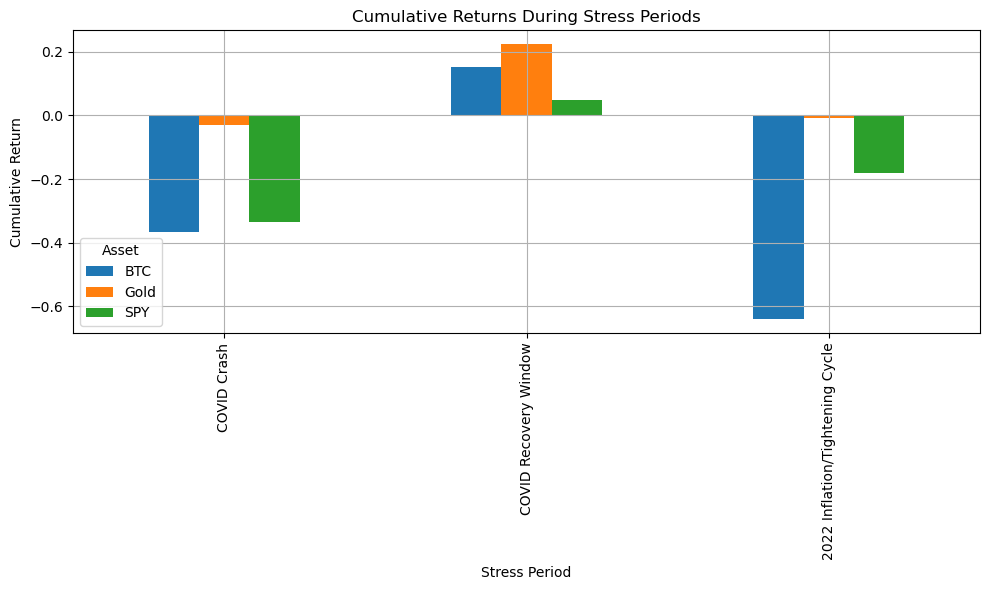

In [34]:
stress_return_table.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Cumulative Returns During Stress Periods")
plt.ylabel("Cumulative Return")
plt.xlabel("Stress Period")
plt.grid(True)
plt.tight_layout()
plt.savefig("../charts/stress_period_cumulative_returns.png")
plt.show()

### STRESS-PERIOD FINDINGS

- This test compares Bitcoin, gold, and equities during major periods of market stress and economic uncertainty.
- During the COVID crash, Bitcoin lost 36.7% of its value, slightly worse than the S&P 500 (-33.4%) and far more than gold (-3.1%), suggesting risk-asset behavior rather than safe-haven characteristics.
- During the COVID recovery, Bitcoin rebounded strongly (+15.2%), consistent with high-beta assets that perform well in risk-on environments.
- During the 2022 inflation and monetary tightening cycle, Bitcoin declined by 64.1%, while gold remained nearly flat (-0.8%), indicating that Bitcoin did not provide meaningful inflation protection.
- Overall, Bitcoin's behavior during stress periods more closely resembles a speculative growth asset than a traditional store of value such as gold.

## Thesis Test 5: Post-2020 Institutionalization

In [35]:
core_assets = ["BTC", "Gold", "SPY"]
def calculate_period_metrics(price_data, return_data):
    metrics = pd.DataFrame(index=core_assets)
    metrics["Annualized Return"] = (
        return_data[core_assets].apply(annualized_return)
    )
    metrics["Annualized Volatility"] = (
        return_data[core_assets].apply(annualized_volatility)
    )
    metrics["Sharpe Ratio"] = (
        return_data[core_assets].apply(sharpe_ratio)
    )
    metrics["Max Drawdown"] = (
        price_data[core_assets].apply(max_drawdown_from_prices)
    )
    return metrics

In [36]:
pre_2020_prices = prices.loc[:'2019-12-31']
pre_2020_returns = returns.loc[:'2019-12-31']

post_2020_prices = prices.loc['2020-01-01':]
post_2020_returns = returns.loc['2020-01-01':]

pre_2020_metrics = calculate_period_metrics(
    pre_2020_prices,
    pre_2020_returns
)

post_2020_metrics = calculate_period_metrics(
    post_2020_prices,
    post_2020_returns)

print("PRE-2020")
display(pre_2020_metrics)

print("POST-2020")
display(post_2020_metrics)

PRE-2020


,Annualized Return,Annualized Volatility,Sharpe Ratio,Max Drawdown
BTC,0.872263,0.728285,1.197695,-0.830363
Gold,0.046192,0.125659,0.367594,-0.197477
SPY,0.116015,0.134275,0.864009,-0.193489


POST-2020


,Annualized Return,Annualized Volatility,Sharpe Ratio,Max Drawdown
BTC,0.387551,0.605109,0.640466,-0.766346
Gold,0.158529,0.182726,0.867576,-0.262109
SPY,0.154948,0.203157,0.762702,-0.337173


In [37]:
pre_corr = pre_2020_returns[core_assets].corr()
post_corr = post_2020_returns[core_assets].corr()

print("PRE-2020 CORRELATIONS")
display(pre_corr)

print("POST-2020 CORRELATIONS")
display(post_corr)

PRE-2020 CORRELATIONS


,BTC,Gold,SPY
BTC,1.000000,0.042206,0.016316
Gold,0.042206,1.000000,-0.167998
SPY,0.016316,-0.167998,1.000000


POST-2020 CORRELATIONS


,BTC,Gold,SPY
BTC,1.000000,0.133805,0.379397
Gold,0.133805,1.000000,0.148501
SPY,0.379397,0.148501,1.000000


In [38]:
institutionalization_summary = pd.DataFrame({
    "Metric":[
        "BTC Return",
        "BTC Volatility",
        "BTC Max Drawdown",
        "BTC-SPY Correlation",
        "BTC-Gold Correlation"
    ],
    "Pre-2020":[
        pre_2020_metrics.loc["BTC","Annualized Return"],
        pre_2020_metrics.loc["BTC","Annualized Volatility"],
        pre_2020_metrics.loc["BTC","Max Drawdown"],
        pre_corr.loc["BTC","SPY"],
        pre_corr.loc["BTC","Gold"]
    ],
    "Post-2020":[
        post_2020_metrics.loc["BTC","Annualized Return"],
        post_2020_metrics.loc["BTC","Annualized Volatility"],
        post_2020_metrics.loc["BTC","Max Drawdown"],
        post_corr.loc["BTC","SPY"],
        post_corr.loc["BTC","Gold"]
    ]
})
institutionalization_summary

,Metric,Pre-2020,Post-2020
0,BTC Return,0.872263,0.387551
1,BTC Volatility,0.728285,0.605109
2,BTC Max Drawdown,-0.830363,-0.766346
3,BTC-SPY Correlation,0.016316,0.379397
4,BTC-Gold Correlation,0.042206,0.133805


### POST-2020 INSTITUTIONALIZATION FINDINGS

- Bitcoin's annualized returns declined after 2020 but remained substantially higher than traditional assets.
- Bitcoin's volatility decreased following increased institutional participation, suggesting a more mature market structure.
- BTC-SPY correlation increased dramatically from near zero to approximately 0.38, indicating stronger integration with broader financial markets.
- BTC-Gold correlation remained weak both before and after 2020, providing little evidence that Bitcoin is evolving into a gold-like asset.
- Overall, institutional adoption appears to have transformed Bitcoin into a more mature and institutionally accepted risk asset rather than a digital equivalent of gold.

## Thesis Test 6: Portfolio Role

In [39]:
portfolio_weights = {
    "60/40 SPY-Gold": {
        "BTC": 0.00,
        "SPY": 0.60,
        "Gold": 0.40
    },
    "5% BTC": {
        "BTC": 0.05,
        "SPY": 0.57,
        "Gold": 0.38
    },
    "10% BTC": {
        "BTC": 0.10,
        "SPY": 0.54,
        "Gold": 0.36
    },
    "20% BTC": {
        "BTC": 0.20,
        "SPY": 0.48,
        "Gold": 0.32
    }
}
portfolio_weights

{'60/40 SPY-Gold': {'BTC': 0.0, 'SPY': 0.6, 'Gold': 0.4},
 '5% BTC': {'BTC': 0.05, 'SPY': 0.57, 'Gold': 0.38},
 '10% BTC': {'BTC': 0.1, 'SPY': 0.54, 'Gold': 0.36},
 '20% BTC': {'BTC': 0.2, 'SPY': 0.48, 'Gold': 0.32}}

In [40]:
portfolio_returns = pd.DataFrame(index=returns.index)
for portfolio_name, weights in portfolio_weights.items():
    portfolio_returns[portfolio_name] = (
        returns["BTC"] * weights["BTC"] +
        returns["SPY"] * weights["SPY"] +
        returns["Gold"] * weights["Gold"]
    )
portfolio_returns.head()

,60/40 SPY-Gold,5% BTC,10% BTC,20% BTC
2015-01-05,-0.004805,-0.011002,-0.017199,-0.029592
2015-01-06,-0.001092,0.001097,0.003286,0.007663
2015-01-07,0.005120,0.006288,0.007455,0.009790
2015-01-08,0.008963,0.006649,0.004334,-0.000295
2015-01-09,-0.000254,0.001004,0.002263,0.004779


In [41]:
def portfolio_max_drawdown(return_series):
    portfolio_growth = (1 + return_series).cumprod()
    running_max = portfolio_growth.cummax()
    drawdown = portfolio_growth / running_max - 1
    return drawdown.min()

portfolio_metrics = pd.DataFrame(index=portfolio_returns.columns)

portfolio_metrics["Annualized Return"] = portfolio_returns.apply(annualized_return)
portfolio_metrics["Annualized Volatility"] = portfolio_returns.apply(annualized_volatility)
portfolio_metrics["Sharpe Ratio"] = portfolio_returns.apply(sharpe_ratio)
portfolio_metrics["Max Drawdown"] = portfolio_returns.apply(portfolio_max_drawdown)
portfolio_metrics

,Annualized Return,Annualized Volatility,Sharpe Ratio,Max Drawdown
60/40 SPY-Gold,0.133141,0.127426,1.044849,-0.225533
5% BTC,0.163588,0.132921,1.230711,-0.229155
10% BTC,0.193611,0.145484,1.330799,-0.246601
20% BTC,0.252095,0.185371,1.359949,-0.315252


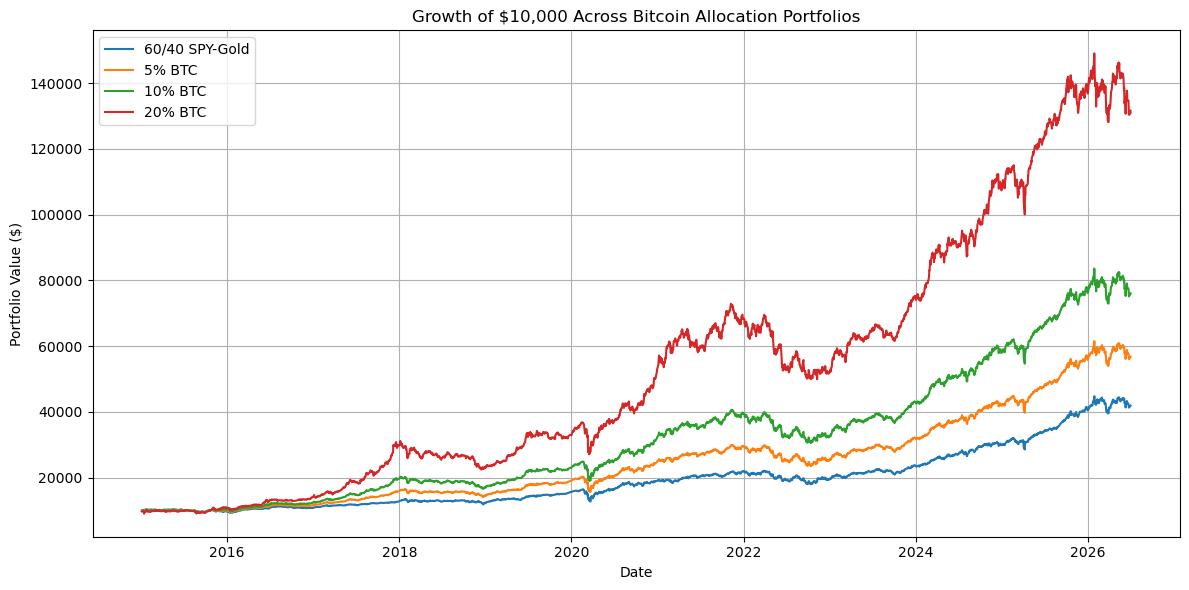

In [42]:
initial_investment = 10_000
portfolio_growth = (1 + portfolio_returns).cumprod() * initial_investment
plt.figure(figsize=(12, 6))
for portfolio in portfolio_growth.columns:
    plt.plot(
        portfolio_growth.index,
        portfolio_growth[portfolio],
        label=portfolio
    )
plt.title("Growth of $10,000 Across Bitcoin Allocation Portfolios")
plt.xlabel("Date")
plt.ylabel("Portfolio Value ($)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("../charts/portfolio_growth_btc_allocations.png")
plt.show()

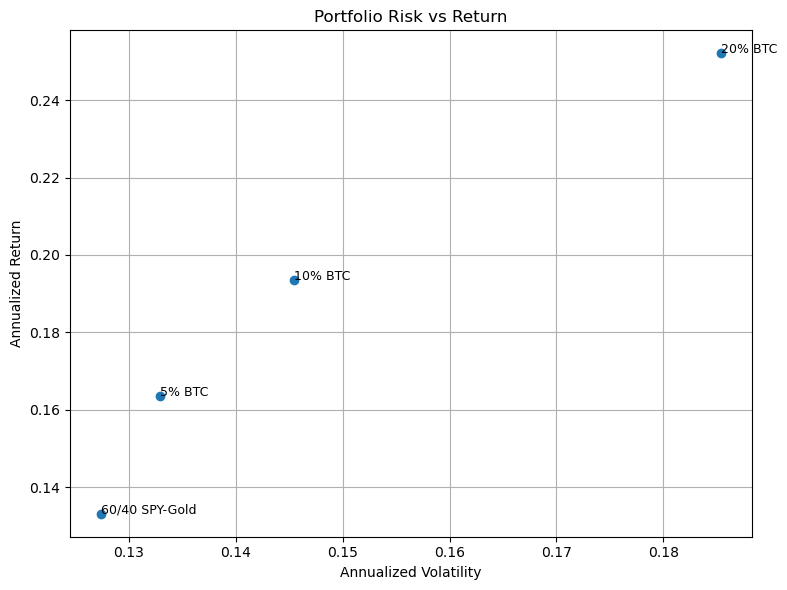

In [43]:
plt.figure(figsize=(8, 6))
plt.scatter(
    portfolio_metrics["Annualized Volatility"],
    portfolio_metrics["Annualized Return"]
)
for portfolio in portfolio_metrics.index:
    plt.text(
        portfolio_metrics.loc[portfolio, "Annualized Volatility"],
        portfolio_metrics.loc[portfolio, "Annualized Return"],
        portfolio,
        fontsize=9
    )
plt.title("Portfolio Risk vs Return")
plt.xlabel("Annualized Volatility")
plt.ylabel("Annualized Return")
plt.grid(True)
plt.tight_layout()
plt.savefig("../charts/portfolio_risk_return.png")
plt.show()

### PORTFOLIO ROLE FINDINGS

- Adding Bitcoin increased both portfolio returns and volatility across all allocation levels.
- Small Bitcoin allocations (5–10%) improved risk-adjusted performance, as measured by the Sharpe ratio, while only modestly increasing drawdowns.
- Higher allocations (20%) generated the strongest returns but also produced substantially larger losses during market downturns.
- These results suggest that Bitcoin provides diversification benefits despite its high volatility because its correlation with traditional assets remains imperfect.
- Therefore, Bitcoin's role in a portfolio may be justified as a speculative diversifier and return enhancer rather than as a direct substitute for gold or a traditional safe-haven asset.